<a href="https://colab.research.google.com/github/mdrehantabish123/mdrehantabish123-Data_Science_Lab_SE_A_38/blob/main/experiment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/retail_sales_dataset.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
# Check for missing values
print("\nMissing values:")
display(df.isnull().sum())


Missing values:


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [11]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Calculate Total Sales
total_sales = df['Total Amount'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

# Calculate Total Units Sold
total_units_sold = df['Quantity'].sum()
print(f"Total Units Sold: {total_units_sold}")

# Top 5 Products by Sales
top_5_products = df.groupby('Product Category')['Total Amount'].sum().nlargest(5)
print("\nTop 5 Products by Sales:")
print(top_5_products.to_string())

# Sales by Gender
sales_by_gender = df.groupby('Gender')['Total Amount'].sum()
print("\nSales by Gender:")
print(sales_by_gender.to_string())

Total Sales: $456,000.00
Total Units Sold: 2514

Top 5 Products by Sales:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515

Sales by Gender:
Gender
Female    232840
Male      223160


In [12]:
# Monthly Sales Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum().to_frame()
monthly_sales.index = monthly_sales.index.astype(str) # Convert PeriodIndex to string for plotting
print("\nMonthly Sales Trend:")
print(monthly_sales.to_string())


Monthly Sales Trend:
         Total Amount
Month                
2023-01         35450
2023-02         44060
2023-03         28990
2023-04         33870
2023-05         53150
2023-06         36715
2023-07         35465
2023-08         36960
2023-09         23620
2023-10         46580
2023-11         34920
2023-12         44690
2024-01          1530


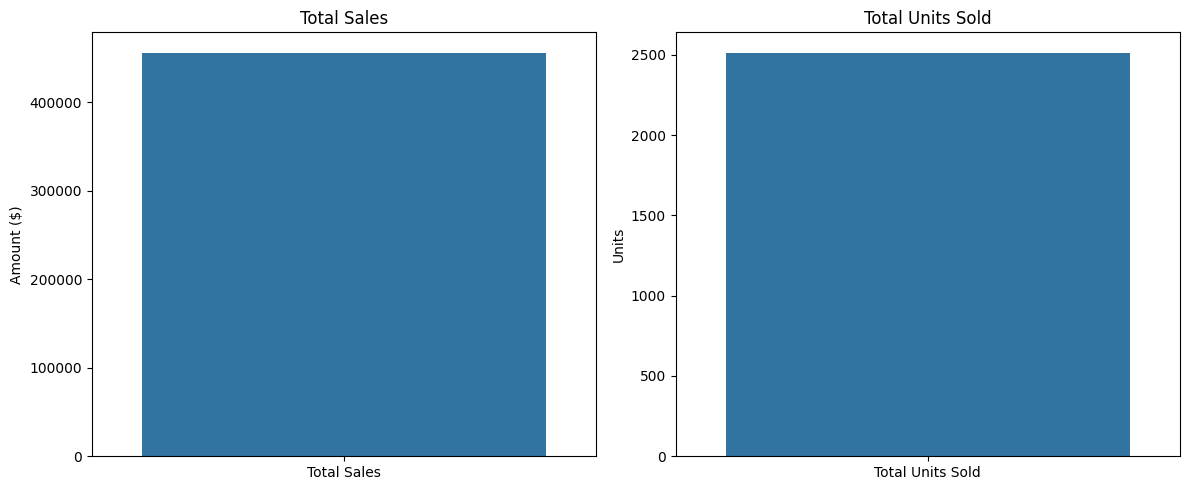

In [13]:
# Visualize Total Sales and Total Units Sold
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=['Total Sales'], y=[total_sales], ax=axes[0])
axes[0].set_title('Total Sales')
axes[0].set_ylabel('Amount ($)')

sns.barplot(x=['Total Units Sold'], y=[total_units_sold], ax=axes[1])
axes[1].set_title('Total Units Sold')
axes[1].set_ylabel('Units')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6843/2269944832.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_products.index, y=top_5_products.values, palette='viridis')


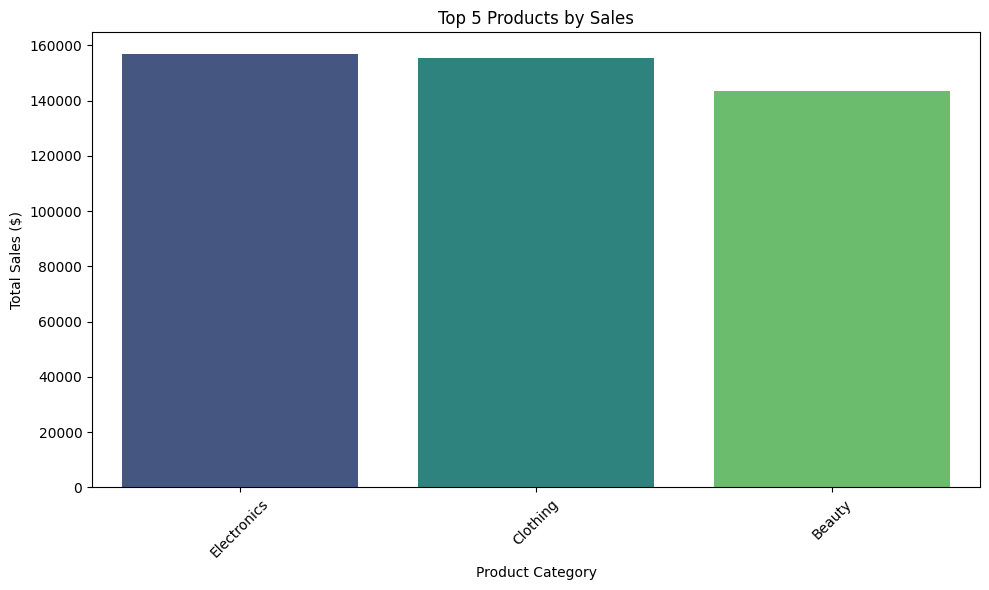

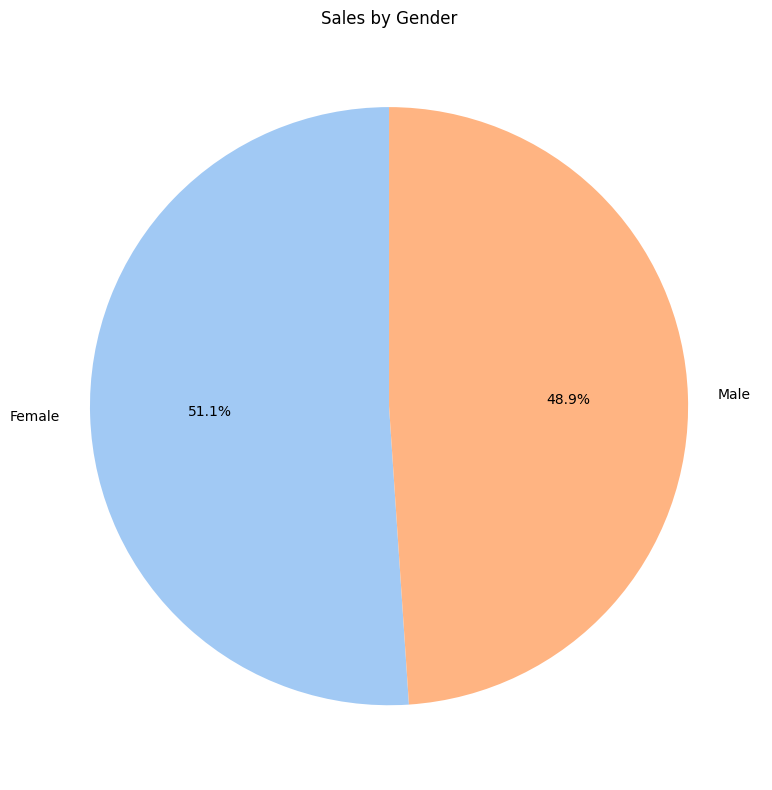

In [14]:
# Visualize Top 5 Products by Sales (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_products.index, y=top_5_products.values, hue=top_5_products.index, palette='viridis', legend=False)
plt.title('Top 5 Products by Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize Sales by Gender (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(sales_by_gender, labels=sales_by_gender.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Sales by Gender')
plt.tight_layout()
plt.show()

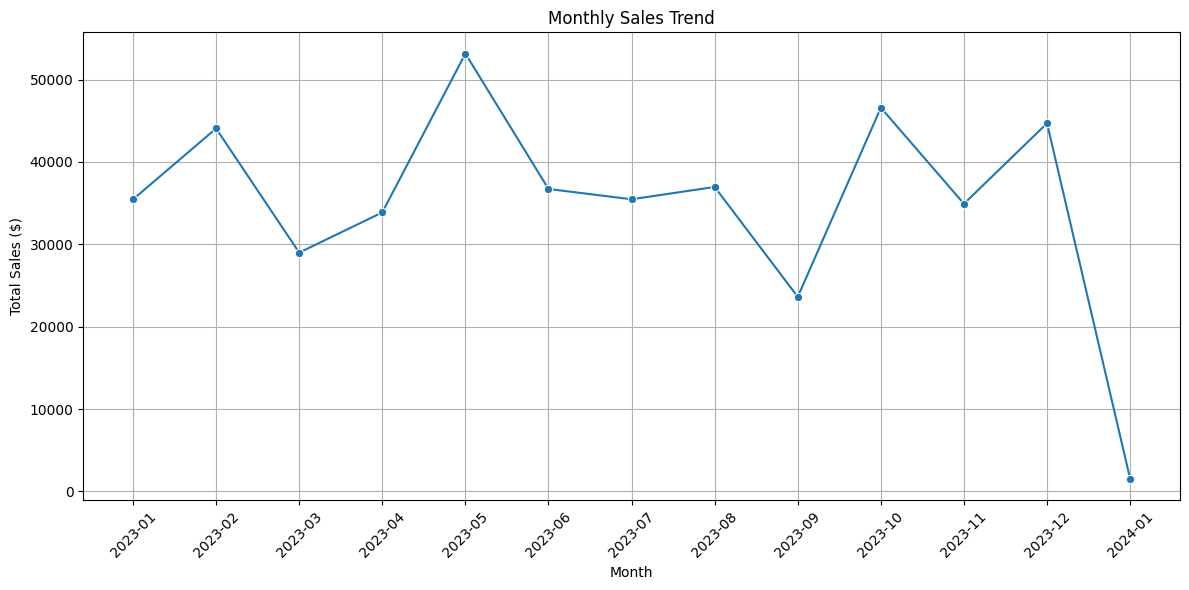

In [15]:
# Visualize Monthly Sales Trend (Line Chart)
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales.index, y='Total Amount', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Calculate Total Sales
total_sales = df['Total Amount'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

# Calculate Total Units Sold
total_units_sold = df['Quantity'].sum()
print(f"Total Units Sold: {total_units_sold}")

Total Sales: $456,000.00
Total Units Sold: 2514


In [6]:
# Top 5 Products by Sales
top_5_products = df.groupby('Product Category')['Total Amount'].sum().nlargest(5)
print("\nTop 5 Products by Sales:")
print(top_5_products.to_string())

# Sales by Gender
sales_by_gender = df.groupby('Gender')['Total Amount'].sum()
print("\nSales by Gender:")
print(sales_by_gender.to_string())


Top 5 Products by Sales:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515

Sales by Gender:
Gender
Female    232840
Male      223160


In [7]:
# Monthly Sales Trend
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()
print("\nMonthly Sales Trend:")
print(monthly_sales.to_string())


Monthly Sales Trend:
Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M


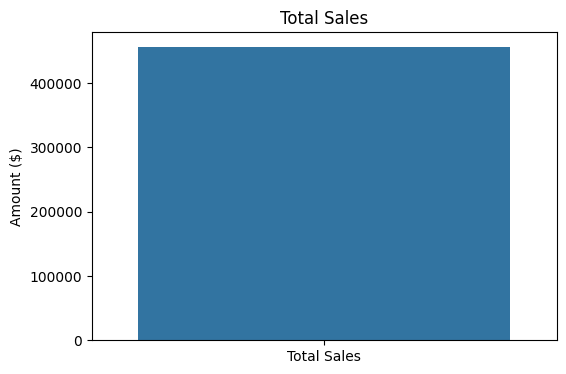

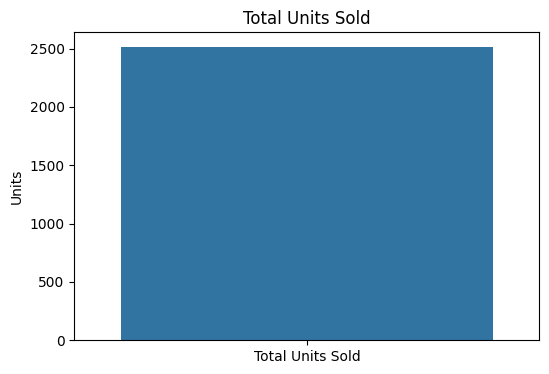

In [8]:
# Visualize Total Sales
plt.figure(figsize=(6, 4))
sns.barplot(x=['Total Sales'], y=[total_sales])
plt.title('Total Sales')
plt.ylabel('Amount ($)')
plt.show()

# Visualize Total Units Sold
plt.figure(figsize=(6, 4))
sns.barplot(x=['Total Units Sold'], y=[total_units_sold])
plt.title('Total Units Sold')
plt.ylabel('Units')
plt.show()

/tmp/ipykernel_6843/2269944832.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_products.index, y=top_5_products.values, palette='viridis')


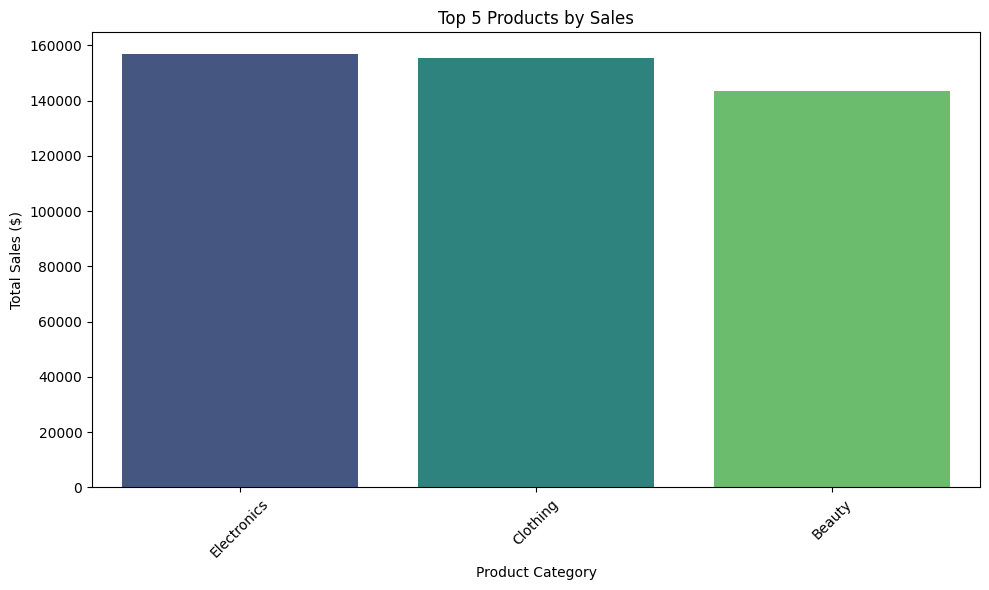

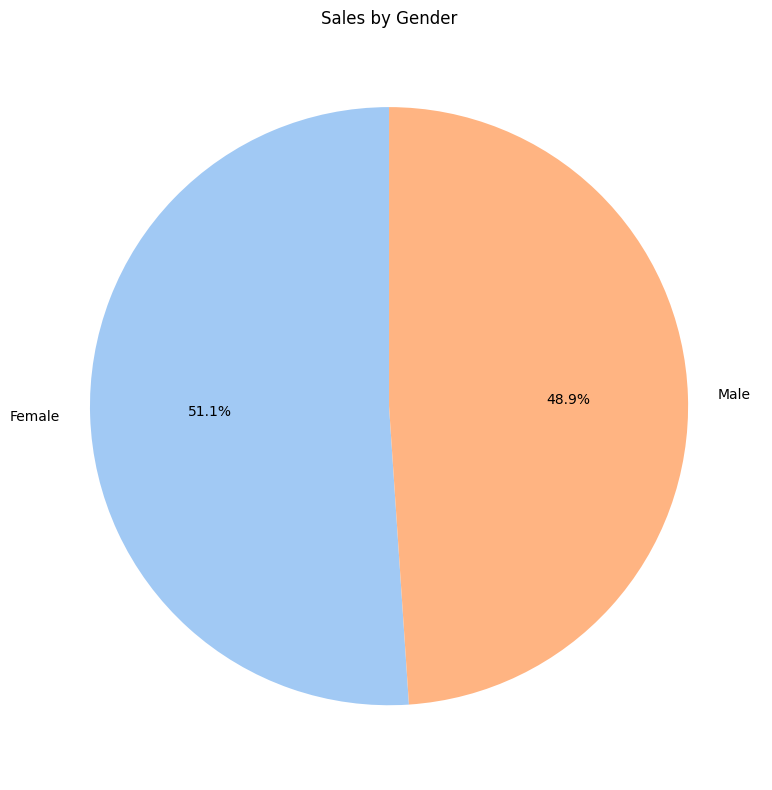

In [9]:
# Visualize Top 5 Products by Sales (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_products.index, y=top_5_products.values, hue=top_5_products.index, palette='viridis', legend=False)
plt.title('Top 5 Products by Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize Sales by Gender (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(sales_by_gender, labels=sales_by_gender.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Sales by Gender')
plt.tight_layout()
plt.show()

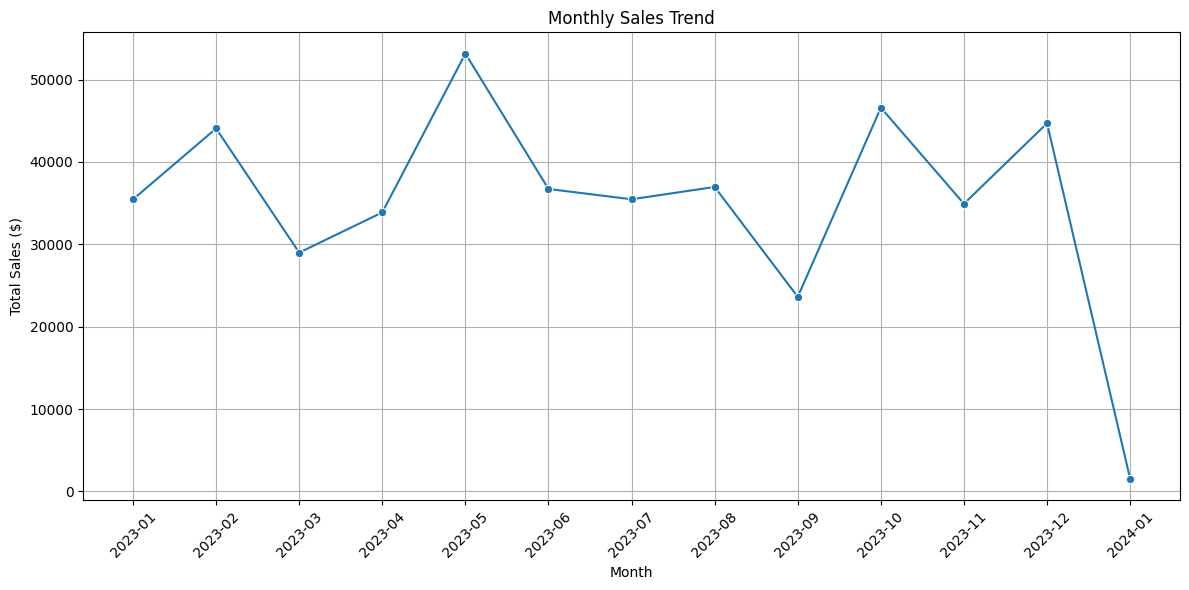

In [10]:
# Visualize Monthly Sales Trend (Line Chart)
plt.figure(figsize=(12, 6))
monthly_sales.index = monthly_sales.index.astype(str) # Convert PeriodIndex to string for plotting
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()